# 人脸图像生成

In [1]:
%matplotlib inline
import torch
from torch import nn
import torchvision
import GanUtil
import matplotlib.pyplot as plt
import numpy as np

## 数据集


加载数据


In [2]:
train_data = torchvision.datasets.ImageFolder('data/celeba',
                                              transform=torchvision.transforms.Compose([
                                                  torchvision.transforms.CenterCrop((178, 178)),
                                                  torchvision.transforms.Resize((128, 128)),
                                                  torchvision.transforms.ToTensor(),
                                                  # 归一化到 [-1, 1] 配合 Tanh 输出，rgb 三通道
                                                  torchvision.transforms.Normalize((0.5, 0.5, 0.5),
                                                                                   (0.5, 0.5, 0.5))
                                              ]))

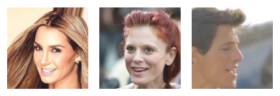

torch.Size([3, 128, 128])

In [3]:
GanUtil.show_images([train_data[i][0] for i in range(3)], figsize=(4, 4))
train_data[0][0].shape

数据加载器


In [4]:
def get_dataloader(batch_size, num_workers=6):
    return torch.utils.data.DataLoader(train_data,
                                       batch_size=batch_size,
                                       shuffle=True,
                                       drop_last=True,
                                       num_workers=num_workers)

dataloader = get_dataloader(batch_size=1)

## 鉴别器
这次用 CNN 来做鉴别器


In [5]:
def Dnet():
    return nn.Sequential(
        # 输入 (3, 128, 128) 忽略批量维
        nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1), # (16, 64, 64)
        nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), # (32, 32, 32)
        nn.BatchNorm2d(32), nn.LeakyReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # (64, 16, 16)
        nn.BatchNorm2d(64), nn.LeakyReLU(),
        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (128, 8, 8)
        nn.BatchNorm2d(128), nn.LeakyReLU(),
        nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # (256, 4, 4)
        nn.BatchNorm2d(256), nn.LeakyReLU(),
        nn.AdaptiveAvgPool2d((1, 1)), # (256, 1, 1)
        nn.Flatten(), # (256)
        nn.Linear(256, 1) # 不加 sigmoid，配合 BCEWithLogitsLoss
    )

检查鉴别器


In [6]:
def random_source(batch_size: int=1):
    """随机生成一个样本"""
    return torch.rand(batch_size, 3, 128, 128) * 2 - 1

D = GanUtil.Discriminator(Dnet())
D(random_source())

tensor([[-0.2938]], grad_fn=<AddmmBackward0>)

测试鉴别器


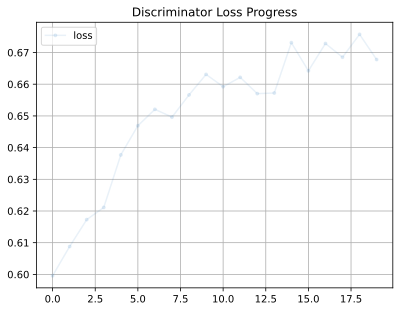

In [7]:
for i, (data, label) in enumerate(dataloader):
    # 真数据
    D.fit(data[:1], GanUtil.right(), verbose=True)
    # 假数据
    D.fit(random_source(), GanUtil.wrong(), verbose=True)
    if i > 100:
        break
D.plot_progress()

In [8]:
for i in range(4):
    print(f"真数据: {D(data[:1]).item():.4f}, 假数据: {D(random_source()).item():.4f}")

真数据: 0.1640, 假数据: -0.0812
真数据: 0.1640, 假数据: -0.0684
真数据: 0.1640, 假数据: -0.0709
真数据: 0.1640, 假数据: -0.0716


## 生成器
转置卷积实现生成器


In [9]:
# 固定种子大小（G输入维度）
seed_size = 100
def seed(input_len: int=seed_size, batch_size: int=1, device: torch.device=torch.device('cpu')):
    """生成正态分布种子"""
    return torch.randn(batch_size, input_len, device=device)

定义生成器


In [10]:
class View(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape
    def forward(self, x):
        return x.view(*self.shape)

def Gnet():
    return nn.Sequential(
        # 输入 (seed_size) 忽略批量维
        nn.Linear(seed_size, 256 * 4 * 4), # (256 * 4 * 4)
        nn.BatchNorm1d(256 * 4 * 4), nn.LeakyReLU(),
        View((-1, 256, 4, 4)), # (256, 4, 4)
        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # (128, 8, 8)
        nn.BatchNorm2d(128), nn.LeakyReLU(),
        nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1), # (64, 16, 16)
        nn.BatchNorm2d(64),  nn.LeakyReLU(),
        nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1), # (32, 32, 32)
        nn.BatchNorm2d(32),  nn.LeakyReLU(),
        nn.ConvTranspose2d(32,  16,  kernel_size=4, stride=2, padding=1), # (16, 64, 64)
        nn.BatchNorm2d(16),  nn.LeakyReLU(),
        nn.ConvTranspose2d(16,  3,   kernel_size=4, stride=2, padding=1), # (3, 128, 128)
        nn.Tanh(), # 输出归一化到 [-1, 1]
    )

测试生成器


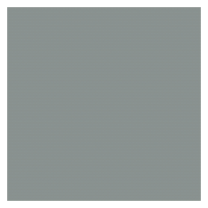

In [11]:
G = GanUtil.Generator(Gnet())
GanUtil.show_tensor_images(G.generate(seed()).reshape(-1, 3, 128, 128), figsize=(3, 3))

## 训练 GAN


[checkpoint] 已加载 ./checkpoint/celeba


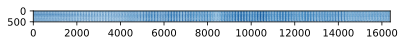

In [12]:
D = GanUtil.Discriminator(Dnet())
G = GanUtil.Generator(Gnet())
checkpoint = GanUtil.load_checkpoint(D, G, './checkpoint/celeba')
epoch_tensor = torch.stack(checkpoint['extra']['epoch_tensor'])
img_list = checkpoint['extra']['img_list']
plt.imshow(np.array(img_list), cmap='Blues')

Epoch 1, Step 100, D Loss: 0.485, G Loss: 1.116
Epoch 1, Step 200, D Loss: 0.368, G Loss: 1.531
Epoch 1, Step 300, D Loss: 0.336, G Loss: 1.854
Epoch 1, Step 400, D Loss: 0.329, G Loss: 2.017
Epoch 1, Step 500, D Loss: 0.325, G Loss: 2.100
Epoch 1, Step 600, D Loss: 0.349, G Loss: 2.050
Epoch 1, Step 700, D Loss: 0.327, G Loss: 2.113
Epoch 1, Step 800, D Loss: 0.325, G Loss: 2.106
Epoch 1, Step 900, D Loss: 0.365, G Loss: 1.607
Epoch 1, Step 1000, D Loss: 0.345, G Loss: 1.872
Epoch 1, Step 1100, D Loss: 0.505, G Loss: 1.615
Epoch 1, Step 1200, D Loss: 0.369, G Loss: 1.928
Epoch 1, Step 1300, D Loss: 0.424, G Loss: 1.652
Epoch 1, Step 1400, D Loss: 0.611, G Loss: 1.682
Epoch 1, Step 1500, D Loss: 0.548, G Loss: 1.447
Epoch 1, Step 1600, D Loss: 0.602, G Loss: 1.171
Epoch 1, Step 1700, D Loss: 0.547, G Loss: 1.292
Epoch 1, Step 1800, D Loss: 0.647, G Loss: 0.989
Epoch 1, Step 1900, D Loss: 0.400, G Loss: 1.651
Epoch 1, Step 2000, D Loss: 0.574, G Loss: 1.638
Epoch 1, Step 2100, D Loss: 0

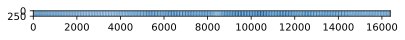

In [19]:
device = GanUtil.get_device()
dataloader = get_dataloader(batch_size=64, num_workers=20)
D = GanUtil.Discriminator(Dnet(), lr=2e-4).to(device)
G = GanUtil.Generator(Gnet(), lr=4e-4).to(device)
epoch_tensor = GanUtil.train_gan_dataloader(D, G, dataloader, seed,
                                            num_epochs=4,
                                            device=device,
                                            show_evolve=True,
                                            evolve_interval=50,
                                            save_path='./image/celeba/evolve.png',
                                            checkpoint_path='./checkpoint/celeba')

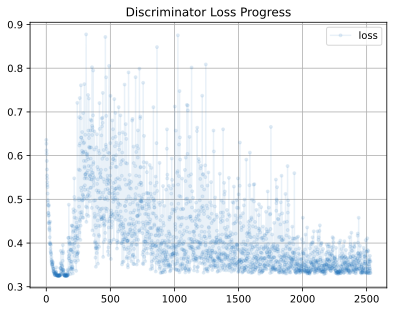

In [20]:
D.plot_progress(save_path='./image/celeba/D-loss.png')

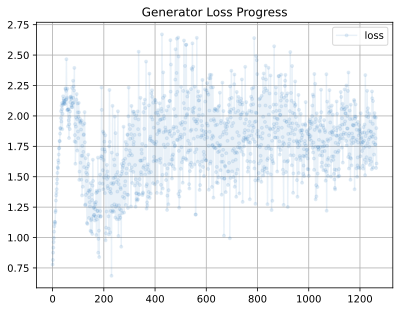

In [21]:
G.plot_progress(save_path='./image/celeba/G-loss.png')

每一轮的生成


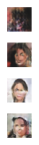

In [22]:
GanUtil.show_tensor_images(epoch_tensor.view(-1, 3, 128, 128),
                           figsize=(10, 10),
                           rows=20,
                           save_path='./image/celeba/epoch_gen.png')

尝试生成样本


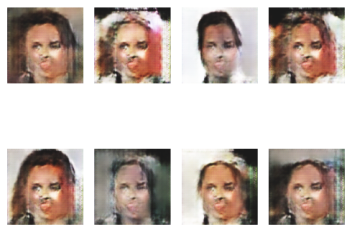

In [23]:
image_tensor = torch.stack([G.generate(seed().to(device)).squeeze(0) for _ in range(8)], dim=0)
GanUtil.show_tensor_images(image_tensor, figsize=(5, 5), rows=2,
                           save_path='./image/celeba/output-sample.png')

In [24]:
torch.save(D.state_dict(), './model/celeba/D.pth')
torch.save(G.state_dict(), './model/celeba/G.pth')
torch.save(epoch_tensor, './model/celeba/epoch_tensor.pth')

RuntimeError: Parent directory ./model/celeba does not exist.